# Long Short-Term Memory (LSTM)

Dataset:
IMDb Movie Reviews

Task:
Binary Sentiment Classification

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

In [2]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#Pad Sequence

Makes every review exactly 200 words long.

In [3]:
max_length = 200

X_train = pad_sequences(X_train,
                        maxlen=max_length,
                        padding='post')

X_test = pad_sequences(X_test,
                       maxlen=max_length,
                       padding='post')

#Build LSTM Model

In [4]:
model = Sequential()

model.add(Embedding(input_dim=vocab_size,
                    output_dim=32,
                    input_length=max_length))

model.add(LSTM(32))

model.add(Dense(1,
                activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


The Embedding layer converts words into vectors. The LSTM layer contains memory cells.

##Unlike SimpleRNN, LSTM decides :

Should I remember this?

Should I forget this?

Should I use this later?

##Instead of one hidden state, LSTM maintains :

Hidden State (Short-Term Memory) + Cell State (Long-Term Memory)

#How LSTM Works

Chapter 1

↓

Chapter 2

↓

Chapter 3

↓

Chapter 20

You don't remember every sentence.

##Instead you remember

main

characters

story

relationships

important events

##LSTM behaves similarly.

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#Compile Model

In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#Train Model

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 89ms/step - accuracy: 0.5634 - loss: 0.6766 - val_accuracy: 0.5732 - val_loss: 0.6579
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 88ms/step - accuracy: 0.6087 - loss: 0.6206 - val_accuracy: 0.6440 - val_loss: 0.5562
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 91ms/step - accuracy: 0.6266 - loss: 0.6588 - val_accuracy: 0.5808 - val_loss: 0.6615
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.6596 - loss: 0.5945 - val_accuracy: 0.7916 - val_loss: 0.5240
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 91ms/step - accuracy: 0.6691 - loss: 0.6177 - val_accuracy: 0.6592 - val_loss: 0.6216


#Evaluate

In [8]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.6469 - loss: 0.6269
Test Accuracy: 0.6468799710273743


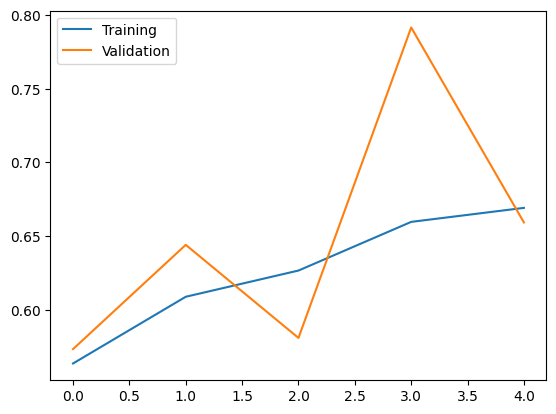

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(["Training","Validation"])
plt.show()

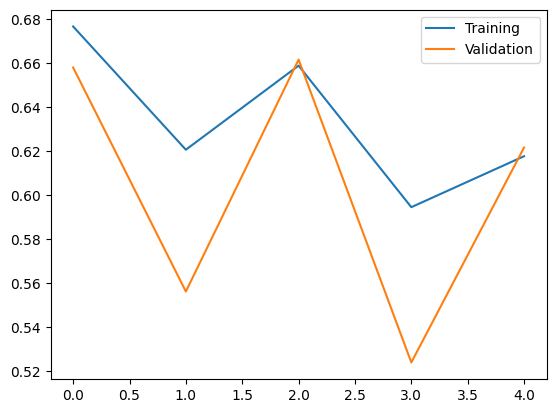

In [10]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(["Training","Validation"])
plt.show()

In [12]:
prediction = model.predict(X_test[:10])

for i,p in enumerate(prediction):

    print("Review",i+1)

    if p>0.5:
        print("Positive")
    else:
        print("Negative")

    print("Actual:",y_test[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
Review 1
Negative
Actual: 0
Review 2
Positive
Actual: 1
Review 3
Negative
Actual: 1
Review 4
Negative
Actual: 0
Review 5
Negative
Actual: 1
Review 6
Negative
Actual: 1
Review 7
Positive
Actual: 1
Review 8
Negative
Actual: 0
Review 9
Negative
Actual: 0
Review 10
Negative
Actual: 1
